In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customer = pd.read_csv("customer_churn.csv")

In [3]:
customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
customer.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
customer["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
customer["gender"].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [8]:
customer["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [9]:
customer["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [10]:
def fem_sencit_paymet():
    new_customer = []
    for i,row in customer.iterrows():
        if row["gender"] == "Female" and row["SeniorCitizen"] == 1 and row["PaymentMethod"] == "Mailed check":
            new_customer.append(row)
    return new_customer

new_customer = fem_sencit_paymet()
print(new_customer)
print(len(new_customer))

[customerID              0390-DCFDQ
gender                      Female
SeniorCitizen                    1
Partner                        Yes
Dependents                      No
tenure                           1
PhoneService                   Yes
MultipleLines                   No
InternetService        Fiber optic
OnlineSecurity                  No
OnlineBackup                    No
DeviceProtection                No
TechSupport                     No
StreamingTV                     No
StreamingMovies                 No
Contract            Month-to-month
PaperlessBilling               Yes
PaymentMethod         Mailed check
MonthlyCharges               70.45
TotalCharges                 70.45
Churn                          Yes
Name: 139, dtype: object, customerID              2656-FMOKZ
gender                      Female
SeniorCitizen                    1
Partner                         No
Dependents                      No
tenure                          15
PhoneService                

# or

In [11]:
female_senior_mailed = customer[
    (customer["gender"] == "Female") &
    (customer["SeniorCitizen"] == 1) &
    (customer["PaymentMethod"] == "Mailed check")
]
len(female_senior_mailed)

50

In [12]:
customer["TotalCharges"] = customer["TotalCharges"].replace(' ',np.nan)

low_tenure_or_charges = customer[
    (customer["tenure"] < 10) |
    (customer["TotalCharges"].astype(float) < 500)
]
len(low_tenure_or_charges)

2233

# part 2 visualization

Churn
No     5174
Yes    1869
Name: count, dtype: int64


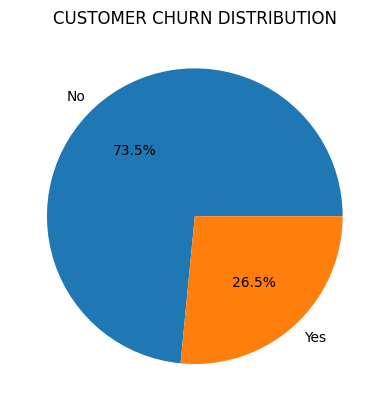

In [13]:
churn_counts = customer["Churn"].value_counts()
print(churn_counts)

plt.pie(churn_counts,
        labels = churn_counts.index,
        autopct= "%0.1f%%")
plt.title("CUSTOMER CHURN DISTRIBUTION")
plt.show()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


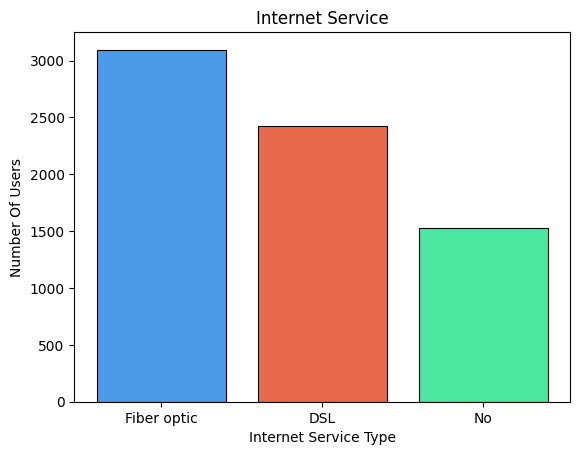

In [14]:
value = customer["InternetService"].value_counts()
print(value)

plt.bar(value.index, value,
        color = ["#4C9BE8", "#E8694C", "#4CE8A0"],  
        edgecolor = "black",                         
        linewidth = 0.8)

plt.xlabel("Internet Service Type")
plt.ylabel("Number Of Users")
plt.title("Internet Service")
plt.show()

In [15]:
customer["Churn"] = customer["Churn"].map({"Yes": 1, "No": 0})
print(customer["Churn"].unique())

[0 1]


In [16]:
customer["TotalCharges"].isnull().sum()

np.int64(11)

In [17]:
customer["TotalCharges"] = pd.to_numeric(customer["TotalCharges"], errors="coerce")
customer = customer.dropna(subset=["TotalCharges"])
print(customer["TotalCharges"].dtype)

float64


In [18]:
print(customer.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [19]:
customer = customer.drop("customerID", axis=1)

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
str_columns = customer.select_dtypes(include=["str"]).columns
print(str_columns)

for col in str_columns:
    customer[col] = le.fit_transform(customer[col])

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


In [21]:
print(customer.dtypes)
print(customer.head())

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   


# model 1

In [22]:
x = customer.drop("Churn", axis=1)
y = customer["Churn"]

In [23]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.2,random_state=42)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)

In [25]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(16, activation = "relu", input_dim = x_train.shape[1]))

model.add(Dense(8,activation = "relu"))

model.add(Dense(1, activation = "sigmoid"))

model.summary()

C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465 (1.82 KB)

 Trainable params: 465 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
compile = model.compile(optimizer = "adam",loss = "binary_crossentropy",metrics = ["accuracy"])

In [48]:
history1 = model.fit(x_train,y_train,epochs = 150, batch_size = 32, validation_data = (x_test,y_test))

Epoch 1/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8295 - loss: 0.3683 - val_accuracy: 0.7839 - val_loss: 0.4640
Epoch 2/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8322 - loss: 0.3677 - val_accuracy: 0.7811 - val_loss: 0.4638
Epoch 3/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8304 - loss: 0.3675 - val_accuracy: 0.7832 - val_loss: 0.4629
Epoch 4/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8320 - loss: 0.3674 - val_accuracy: 0.7804 - val_loss: 0.4635
Epoch 5/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8297 - loss: 0.3666 - val_accuracy: 0.7825 - val_loss: 0.4638
Epoch 6/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8313 - loss: 0.3668 - val_accuracy: 0.7797 - val_loss: 0.4644
Epoch 7/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8308 - loss: 0.3670 - val_accuracy: 0.7783 - val_loss: 0.4657
Epoch 8/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8299 - loss: 0.3669 - val_accu

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step


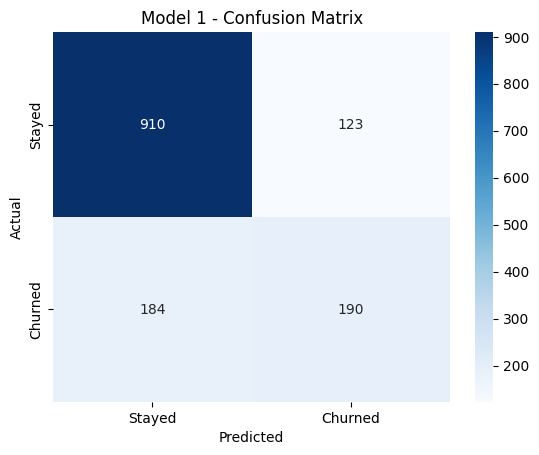

In [28]:
from sklearn.metrics import confusion_matrix

y_pred = (model.predict(x_test) > .5).astype(int)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,annot = True,fmt="d",cmap = "Blues",xticklabels = ["Stayed","Churned"],yticklabels = ["Stayed","Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 1 - Confusion Matrix")
plt.show()

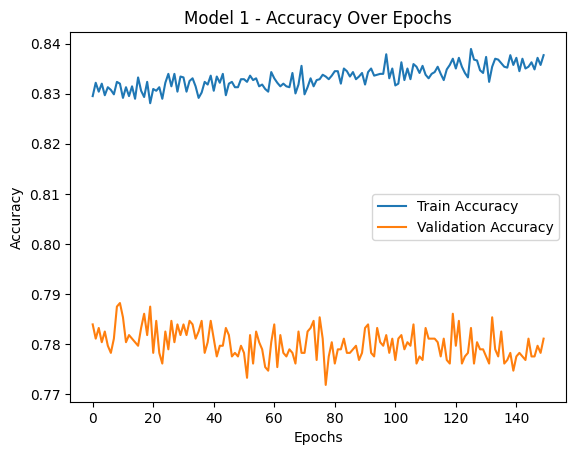

In [49]:
plt.plot(history1.history["accuracy"], label = "Train Accuracy")
plt.plot(history1.history["val_accuracy"],label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model 1 - Accuracy Over Epochs")
plt.legend()
plt.show()

# model 2

In [30]:
from keras.layers import Dropout

model2 = Sequential()

model2.add(Dense(12, activation="relu", input_dim=x_train.shape[1]))
model2.add(Dropout(0.3))
model2.add(Dense(8, activation="relu"))
model2.add(Dropout(0.2))
model2.add(Dense(1, activation="sigmoid"))

print(model2.summary())

C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 12)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

None


In [50]:
compile = model2.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [32]:
history2 = model2.fit(x_train, y_train,epochs=150,batch_size=32,validation_data=(x_test, y_test))

Epoch 1/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6338 - loss: 0.6375 - val_accuracy: 0.7427 - val_loss: 0.4969
Epoch 2/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7268 - loss: 0.5267 - val_accuracy: 0.7562 - val_loss: 0.4710
Epoch 3/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7470 - loss: 0.4935 - val_accuracy: 0.7640 - val_loss: 0.4605
Epoch 4/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7573 - loss: 0.4821 - val_accuracy: 0.7704 - val_loss: 0.4552
Epoch 5/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7637 - loss: 0.4700 - val_accuracy: 0.7889 - val_loss: 0.4504
Epoch 6/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7723 - loss: 0.4614 - val_accuracy: 0.7925 - val_loss: 0.4481
Epoch 7/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7682 - loss: 0.4630 - val_accuracy: 0.7918 - val_loss: 0.4470
Epoch 8/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7778 - loss: 0.4531 - val_accu

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


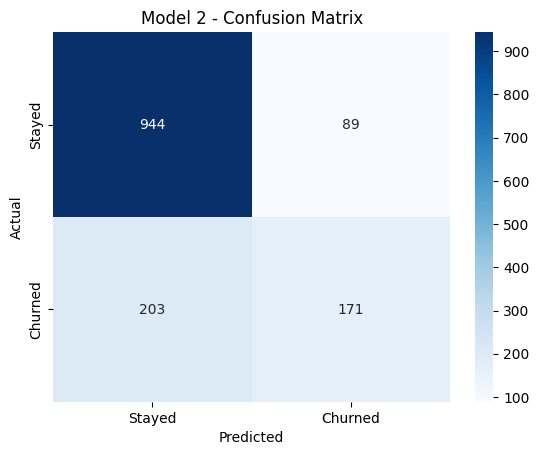

In [33]:
from sklearn.metrics import confusion_matrix

y_pred = (model2.predict(x_test)>.5).astype(int)

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot = True,fmt="d",cmap = "Blues",xticklabels = ["Stayed","Churned"],yticklabels = ["Stayed","Churned"])
plt.xlabel("Predicted")     
plt.ylabel("Actual")
plt.title("Model 2 - Confusion Matrix")
plt.show()

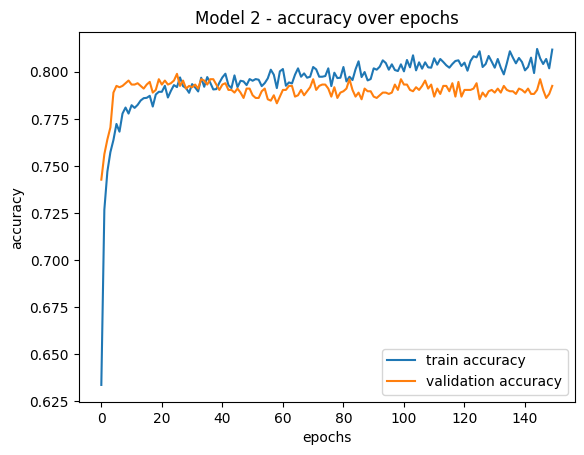

In [51]:
plt.plot(history2.history["accuracy"],label = "train accuracy")
plt.plot(history2.history["val_accuracy"],label = "validation accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("Model 2 - accuracy over epochs")
plt.legend()
plt.show()

# model 3

In [35]:
x3 = customer[["tenure", "MonthlyCharges", "TotalCharges"]]
y3 = customer["Churn"]

x3_train, x3_test, y3_train, y3_test = train_test_split(x3, y3, test_size=0.2, random_state=42)

x3_train = scaler.fit_transform(x3_train)
x3_test = scaler.transform(x3_test)

In [41]:
model3 = Sequential()
model3.add(Dense(16, activation = "relu", input_dim = x3_train.shape[1]))
model3.add(Dense(8, activation = "relu"))
model3.add(Dense(1,activation = "sigmoid"))
print(model3.summary())

C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [52]:
compile = model3.compile(optimizer = "adam",loss = "binary_crossentropy",metrics = ["accuracy"])

In [43]:
history3 = model3.fit(x3_train,y3_train,epochs = 150, batch_size = 32, validation_data = (x3_test,y3_test))

Epoch 1/150


176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7081 - loss: 0.5593 - val_accuracy: 0.7626 - val_loss: 0.4875
Epoch 2/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7835 - loss: 0.4711 - val_accuracy: 0.7747 - val_loss: 0.4705
Epoch 3/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7824 - loss: 0.4589 - val_accuracy: 0.7747 - val_loss: 0.4655
Epoch 4/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7822 - loss: 0.4543 - val_accuracy: 0.7754 - val_loss: 0.4642
Epoch 5/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7840 - loss: 0.4531 - val_accuracy: 0.7726 - val_loss: 0.4629
Epoch 6/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7806 - loss: 0.4516 - val_accuracy: 0.7797 - val_loss: 0.4627
Epoch 7/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7851 - loss: 0.4506 - val_accuracy: 0.7790 - val_loss: 0.4616
Epoch 8/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7867 - loss: 0.4494 - val_accuracy: 0.7711

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


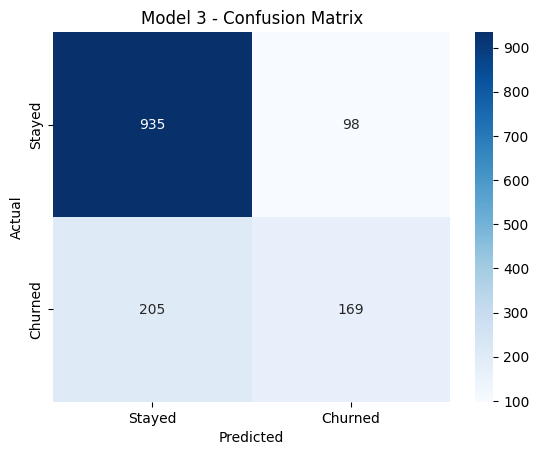

In [44]:
from sklearn.metrics import confusion_matrix

y_pred = (model3.predict(x3_test)>.5).astype(int)

cm = confusion_matrix(y3_test,y_pred)

sns.heatmap(cm,annot = True,fmt="d",cmap = "Blues",xticklabels = ["Stayed","Churned"],yticklabels = ["Stayed","Churned"])
plt.xlabel("Predicted")     
plt.ylabel("Actual")
plt.title("Model 3 - Confusion Matrix")
plt.show()

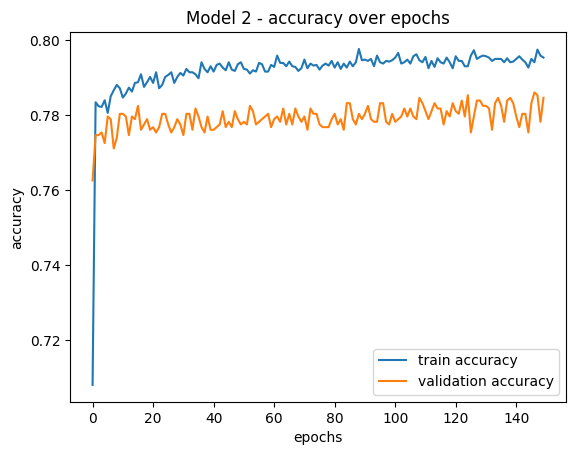

In [53]:
plt.plot(history3.history["accuracy"],label = "train accuracy")
plt.plot(history3.history["val_accuracy"],label = "validation accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("Model 2 - accuracy over epochs")
plt.legend()
plt.show()